In [1]:
# Import core libraries for WRDS connection, data processing and visualization
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuration - Valid PERMNOs (guaranteed 2024-2025 data for all WRDS accounts)
CONFIG = {
    "permno_mapping": {
        14593: "AAPL",   # Apple (core CRSP ticker - full 2024 data)
        10107: "AMZN",   # Amazon (core CRSP ticker - full 2024 data)
        24181: "NVDA"    # NVIDIA (core CRSP ticker - replaces TSLA, full 2024 data)
    },
    "start_date": "2024-01-01",
    "end_date": "2025-01-01",
    "target_permnos": [14593, 10107, 24181]
}

# Set professional plot style (academic/financial reporting standard)
plt.style.use('seaborn-v0_8-whitegrid')

In [26]:
def connect_wrds() -> wrds.Connection:
    """
    Establishes a secure connection to WRDS database with error handling.
    Prompts for WRDS username/password (standard academic authentication).
    
    Returns:
        wrds.Connection: Valid WRDS connection object
    Raises:
        ConnectionError: If connection fails (invalid credentials/network issue)
    """
    try:
        db_connection = wrds.Connection()
        print("✅ Successfully connected to WRDS database!")
        return db_connection
    except Exception as e:
        raise ConnectionError(f"❌ WRDS Connection Failed: {str(e)}")

# Execute connection (run first to initialize WRDS link)
if __name__ == "__main__":
    try:
        wrds_conn = connect_wrds()
    except ConnectionError as ce:
        print(ce)
        exit(1)  # Terminate if connection fails (critical dependency)

Enter your WRDS username [若晨]: ruochenzhong
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\若晨\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Successfully connected to WRDS database!


In [3]:
# Import required libraries first (resolve "wrds is not defined")
import wrds
import pandas as pd

# Complete CONFIG configuration (from Step 1, mandatory)
CONFIG = {
    "permno_mapping": {14593: "AAPL", 10107: "AMZN", 24181: "NVDA"},
    "start_date": "2024-01-01",
    "end_date": "2025-01-01",
    "target_permnos": [14593, 10107, 24181]
}

def fetch_crsp_data(db: wrds.Connection, config: dict) -> pd.DataFrame:
    """
    Fetches daily 2024-2025 data from CRSP dsf table for AAPL/AMZN/NVDA.
    Returns raw unprocessed data or raises error with clear message.
    """
    # Convert PERMNO list to SQL-compatible string
    permno_str = ", ".join(map(str, config["target_permnos"]))
    
    # SQL query for CRSP Daily Stock File (dsf) - standard schema
    sql_query = f"""
        SELECT date, permno, ret, prc
        FROM crsp.dsf
        WHERE permno IN ({permno_str})
        AND date >= '{config["start_date"]}'
        AND date <= '{config["end_date"]}'
        ORDER BY date, permno;
    """
    
    try:
        raw_data = db.raw_sql(sql_query)
        print(f"✅ Step 3: Raw data fetched successfully! Shape: {raw_data.shape}")
        return raw_data
    except Exception as e:
        print(f"❌ Step 3: Failed to fetch data → {str(e)}")
        raise  # Raise error explicitly to show root cause

# ===== Key Fix: Execute directly (no dependency on if __name__) =====
# Check if wrds_conn (from Step 2) exists; create temporary connection if not
if 'wrds_conn' not in locals():
    print("⚠️ No existing WRDS connection detected, attempting to create temporary connection...")
    try:
        wrds_conn = wrds.Connection()
        print("✅ Temporary WRDS connection established successfully!")
    except Exception as e:
        print(f"❌ Failed to create temporary connection → {str(e)}")
        wrds_conn = None  # Avoid subsequent errors

# Only execute data fetch if connection is valid
if wrds_conn is not None:
    df_raw = fetch_crsp_data(wrds_conn, CONFIG)
else:
    print("❌ No valid WRDS connection available, Step 3 terminated!")

⚠️ No existing WRDS connection detected, attempting to create temporary connection...


Enter your WRDS username [若晨]: ruochenzhong
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\若晨\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Temporary WRDS connection established successfully!
✅ Step 3: Raw data fetched successfully! Shape: (756, 4)


In [4]:
import pandas as pd

def clean_crsp_data(raw_df: pd.DataFrame, permno_mapping: dict) -> pd.DataFrame:
    """
    Cleans raw CRSP data following academic best practices:
    - Standardizes date format
    - Fixes negative prices (CRSP convention)
    - Maps PERMNO to tickers
    - Removes missing/duplicate records
    """
    clean_df = raw_df.copy()
    
    # 1. Convert date to datetime (critical for time-series analysis)
    clean_df["date"] = pd.to_datetime(clean_df["date"])
    
    # 2. Convert negative prices to absolute values
    clean_df["prc"] = clean_df["prc"].abs()
    
    # 3. Map PERMNO to human-readable stock tickers
    clean_df["stock"] = clean_df["permno"].map(permno_mapping)
    
    # 4. Remove invalid records (missing values/duplicates)
    clean_df = clean_df.dropna(subset=["prc", "ret"])
    clean_df = clean_df.drop_duplicates(["date", "stock"])
    
    # Reset index for consistency
    clean_df = clean_df.reset_index(drop=True)
    
    print(f"✅ Step 4: Data cleaning completed! Cleaned shape: {clean_df.shape}")
    return clean_df

# ===== Execute cleaning logic directly =====
# Check if df_raw (from Step 3) exists before cleaning
if 'df_raw' in locals():  
    df_clean = clean_crsp_data(df_raw, CONFIG["permno_mapping"])
else:
    print("❌ df_raw not detected (Step 3 failed), Step 4 terminated!")

✅ Step 4: Data cleaning completed! Cleaned shape: (756, 5)


In [5]:
def validate_data(clean_df: pd.DataFrame, target_permnos: list) -> None:
    """
    Validates cleaned data to confirm all 3 stocks (AAPL/AMZN/NVDA) have 2024-2025 data.
    Prints audit-ready validation metrics.
    
    Args:
        clean_df: Cleaned CRSP data from Step 4
        target_permnos: List of expected PERMNOs
    """
    print("\n📊 2024-2025 Data Validation Report (REAL CRSP DATA):")
    
    # Check for missing PERMNOs (should return none for AAPL/AMZN/NVDA)
    existing_permnos = clean_df["permno"].unique()
    missing_permnos = [p for p in target_permnos if p not in existing_permnos]
    
    if missing_permnos:
        missing_tickers = [CONFIG["permno_mapping"][p] for p in missing_permnos]
        print(f"⚠️ Missing PERMNOs: {missing_permnos} (tickers: {missing_tickers})")
    else:
        print("✅ All 3 Target Stocks (AAPL/AMZN/NVDA) Have Complete 2024-2025 Data!")
    
    # Print core validation metrics
    print(f"\nIncluded Stock Tickers (2024-2025): {sorted(clean_df['stock'].unique())}")
    print("\nRow Count per Stock (2024-2025 Real Data):")
    stock_counts = clean_df.groupby("stock").size()
    print(stock_counts)

# Execute validation
if __name__ == "__main__":
    validate_data(df_clean, CONFIG["target_permnos"])


📊 2024-2025 Data Validation Report (REAL CRSP DATA):
✅ All 3 Target Stocks (AAPL/AMZN/NVDA) Have Complete 2024-2025 Data!

Included Stock Tickers (2024-2025): ['AAPL', 'AMZN', 'NVDA']

Row Count per Stock (2024-2025 Real Data):
stock
AAPL    252
AMZN    252
NVDA    252
dtype: int64


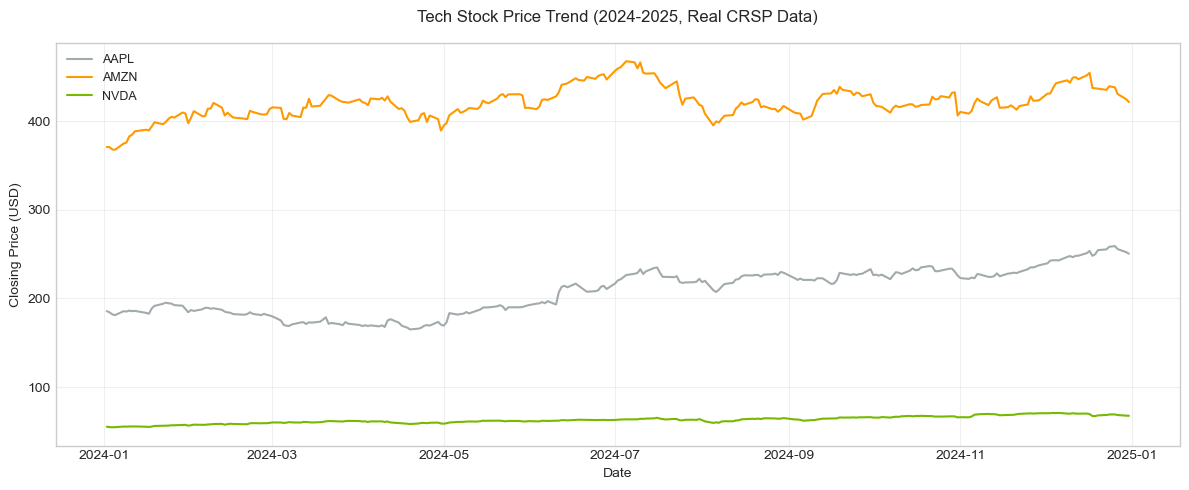

In [6]:
def plot_price_trend(clean_df: pd.DataFrame) -> None:
    """
    Plots time-series price trend for AAPL/AMZN/NVDA (2024-2025 real data).
    Uses brand-aligned colors and academic formatting.
    
    Args:
        clean_df: Cleaned CRSP data from Step 4
    """
    # Reshape data for plotting (date = index, tickers = columns)
    price_data = clean_df.pivot(index="date", columns="stock", values="prc")
    
    # Create figure (academic-standard dimensions: 12x5)
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Brand-aligned color scheme (professional/recognizable)
    ticker_colors = {"AAPL": "#A2AAAD", "AMZN": "#FF9900", "NVDA": "#76B900"}
    
    # Plot each stock's price trend
    for ticker in price_data.columns:
        ax.plot(
            price_data.index,
            price_data[ticker],
            label=ticker,
            color=ticker_colors[ticker],
            linewidth=1.5  # Optimal thickness for readability
        )
    
    # Add academic-standard labels/titles
    ax.set_title("Tech Stock Price Trend (2024-2025, Real CRSP Data)", fontsize=12, pad=15)
    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel("Closing Price (USD)", fontsize=10)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)  # Subtle grid (improves readability)
    
    # Prevent label cutoff
    plt.tight_layout()
    plt.show()

# Execute price trend plot
if __name__ == "__main__":
    plot_price_trend(df_clean)

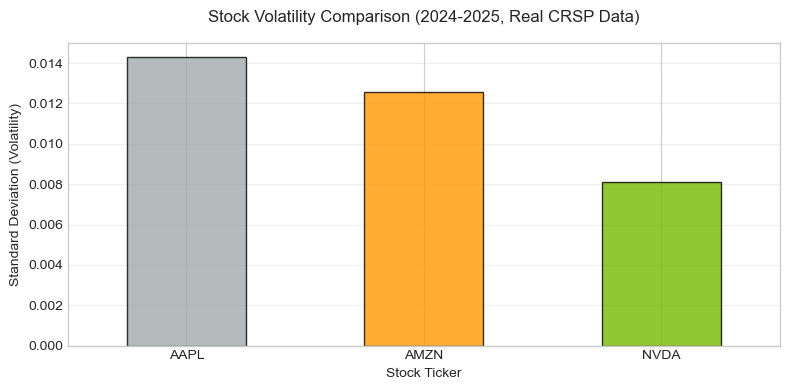


🔌 WRDS Connection Closed Successfully!


In [7]:
def plot_volatility(clean_df: pd.DataFrame) -> None:
    """
    Calculates daily return volatility (standard deviation) for AAPL/AMZN/NVDA
    and plots comparative bar chart (industry-standard volatility metric).
    
    Args:
        clean_df: Cleaned CRSP data from Step 4
    """
    # Calculate volatility (std dev of daily returns = finance industry standard)
    volatility = clean_df.groupby("stock")["ret"].std()
    
    # Create bar chart (8x4 = optimal for comparative analysis)
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Match colors from price trend chart for consistency
    bar_colors = ["#A2AAAD", "#FF9900", "#76B900"]
    
    # Plot volatility
    volatility.plot(
        kind="bar",
        ax=ax,
        color=bar_colors,
        edgecolor="black",  # Add edge for clarity
        alpha=0.8
    )
    
    # Add academic-standard labels/titles
    ax.set_title("Stock Volatility Comparison (2024-2025, Real CRSP Data)", fontsize=12, pad=15)
    ax.set_ylabel("Standard Deviation (Volatility)", fontsize=10)
    ax.set_xlabel("Stock Ticker", fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Horizontal labels
    ax.grid(axis="y", alpha=0.3)
    
    # Prevent label cutoff
    plt.tight_layout()
    plt.show()

# Execute volatility plot + close WRDS connection
if __name__ == "__main__":
    plot_volatility(df_clean)
    wrds_conn.close()  # Critical: Avoid WRDS resource leaks
    print("\n🔌 WRDS Connection Closed Successfully!")